# Predicting Perceived Effectiveness from Multimodal Features

**Thesis modeling — first pass.** Predict the pooled `perceived_effectiveness_z` composite
(built in `analysis/target_index_eda.ipynb`) from:

1. **The 12 features used in the HMM analysis** (`icmi_paper/results/hmm_input_features_final.tsv`)
   — physiology (HR, EDA, temp, pupil), speech/floor dynamics (silence, backchannels, laughter,
   active speakers), and overlap features (count, contested, time, collaboration index).
2. **The new windowed audio/prosodic features**
   (`icmi_paper/results/audio_window_features.tsv`) — energy, pitch mean/sd, HNR — not previously
   available at 30s-window granularity, not used in the HMM.

**Granularity decision:** HMM/audio features are window-level (30s), group-aggregated (no
per-participant signal). The effectiveness target is participant-level. Following the same
convention already used in `icmi_paper/analysis/hmm_state_prediction.ipynb` (self-report outcomes
aggregated to group×task before correlating with HMM states), this notebook aggregates **both**
sides to **group × task** (mean across windows for features, mean across P1–P4 for the target).
That gives n=30 rows (10 groups × 3 tasks: T1–T3, T4 excluded per thesis scope) — small, so the
model section uses grouped cross-validation (leave-one-group-out) and a heavily regularized linear
model rather than anything that can memorize 30 rows.

**Sections:**
1. Load HMM + audio window features, merge
2. Preprocessing (mirrors the HMM notebook's z-scoring / log1p choices; audio features z-scored the same way)
3. Aggregate window-level features to group×task
4. Load and aggregate the effectiveness target to group×task
5. Merge into the final modeling table
6. First model: Ridge regression, leave-one-group-out CV, vs. a mean-only baseline
7. Coefficients / what's driving predictions
8. Conclusions & next steps


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style="whitegrid", font_scale=1.0)
%matplotlib inline

REPO_ROOT = Path.cwd() if (Path.cwd() / "icmi_paper").exists() else Path.cwd().parent
ICMI_RESULTS = REPO_ROOT / "icmi_paper" / "results"
TARGET_PATH = REPO_ROOT / "analysis" / "results" / "perceived_effectiveness_index_participant.tsv"
TASKS = ["T1", "T2", "T3"]

for p in [ICMI_RESULTS / "hmm_input_features_final.tsv", ICMI_RESULTS / "audio_window_features.tsv", TARGET_PATH]:
    assert p.exists(), f"Missing file: {p}"
print("All source files found.")


All source files found.


## 1. Load HMM window features + new audio window features

Both files are window-level (`group_id`, `task_id`, `window_index`), 526 rows, same 10 groups, and
the join keys match exactly (verified: 0 mismatches between the two key sets).


In [2]:
# The 12 features actually used in the HMM (icmi_paper/analysis/hmm_collective_states_updated_overlaps.ipynb, CLEAN_FEATS)
HMM_FEATS = [
    "group_hr_mean_bpm_mean",
    "group_eda_phasic_rate_hz_mean",
    "group_temp_mean_mean",
    "group_et_pupil_mean_mean",
    "tr_silence_duration_s",
    "tr_backchannel_count",
    "tr_laughter_count",
    "tr_n_active_speakers",
    "tr_ovl_count",
    "tr_ovl_contested",
    "tr_ovl_time_s",
    "tr_ovl_collaboration_index",
]

# Curated audio summary features (feature_inventory.md §6 "would add" list) — not gemap_* internals,
# to keep the feature/n ratio sane given only ~30 group×task rows downstream.
AUDIO_FEATS = ["audio_energy_mean", "audio_pitch_mean", "audio_pitch_sd", "audio_hnr_mean"]

KEY = ["group_id", "task_id", "window_index"]

hmm_win = pd.read_csv(ICMI_RESULTS / "hmm_input_features_final.tsv", sep="\t")
audio_win = pd.read_csv(ICMI_RESULTS / "audio_window_features.tsv", sep="\t")

print(f"HMM window features: {hmm_win.shape}")
print(f"Audio window features: {audio_win.shape}")

merged = hmm_win[KEY + HMM_FEATS].merge(audio_win[KEY + AUDIO_FEATS], on=KEY, how="inner")
assert len(merged) == len(hmm_win), "Merge dropped rows — key mismatch between HMM and audio tables"
merged = merged[merged["task_id"].isin(TASKS)].reset_index(drop=True)

print(f"Merged window-level feature table: {merged.shape}")
print(f"Missing values: {merged[HMM_FEATS + AUDIO_FEATS].isnull().sum().sum()}")
merged.head()


HMM window features: (526, 16)
Audio window features: (526, 70)
Merged window-level feature table: (526, 19)
Missing values: 0


,group_id,task_id,window_index,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,tr_ovl_count,tr_ovl_contested,tr_ovl_time_s,tr_ovl_collaboration_index,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean
0,grp-07,T1,0,61.0829,0.2002,36.0375,2.8745,0.000,1.0,0.0,2.0,5.0,4.0,28.978,0.200000,0.109416,23.936003,0.207996,1.817083
1,grp-07,T1,1,61.7098,0.1753,36.0427,2.7528,1.917,0.0,0.0,1.0,4.0,4.0,30.429,0.000000,0.110551,23.453197,0.188979,1.165167
2,grp-07,T1,2,61.7187,0.1668,36.0457,2.8210,2.208,0.0,0.0,3.0,1.0,1.0,0.530,1.000000,0.065333,23.598001,0.195372,0.965169
3,grp-07,T1,3,64.4445,0.1751,36.0486,2.7260,2.189,1.0,0.0,2.0,3.0,2.0,6.770,0.666667,0.040099,13.577585,0.048265,-2.171262
4,grp-07,T1,4,70.7754,0.1588,36.0611,2.6987,10.855,0.0,0.0,2.0,1.0,0.0,0.240,0.000000,0.045782,10.576397,0.062348,-3.440011


## 2. Preprocessing (mirrors the HMM notebook's choices)

- Physiological features (`group_hr_mean_bpm_mean`, `group_eda_phasic_rate_hz_mean`,
  `group_temp_mean_mean`, `group_et_pupil_mean_mean`) → **z-scored within `group_id`** (removes
  session-level baseline drift).
- Right-skewed count/duration features (silence, backchannel, laughter, overlap counts/time,
  collaboration index) → **log1p**.
- New audio features → **z-scored within `group_id`**, same rationale as physio: absolute vocal
  energy/pitch/HNR carries speaker-mix and recording-level baseline differences across sessions
  that within-group standardization removes.


In [3]:
clean = merged.copy()

PHYSIO_Z = ["group_hr_mean_bpm_mean", "group_eda_phasic_rate_hz_mean",
            "group_temp_mean_mean", "group_et_pupil_mean_mean"]
LOG_FEATS = ["tr_silence_duration_s", "tr_backchannel_count", "tr_laughter_count",
             "tr_ovl_count", "tr_ovl_contested", "tr_ovl_time_s", "tr_ovl_collaboration_index"]

for col in PHYSIO_Z + AUDIO_FEATS:
    clean[col] = clean.groupby("group_id")[col].transform(lambda x: (x - x.mean()) / (x.std(ddof=1) + 1e-9))

for col in LOG_FEATS:
    clean[col] = np.log1p(clean[col].clip(lower=0))

FEATURE_COLS = HMM_FEATS + AUDIO_FEATS
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
clean[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(2)


Feature columns (16): ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean', 'group_et_pupil_mean_mean', 'tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count', 'tr_n_active_speakers', 'tr_ovl_count', 'tr_ovl_contested', 'tr_ovl_time_s', 'tr_ovl_collaboration_index', 'audio_energy_mean', 'audio_pitch_mean', 'audio_pitch_sd', 'audio_hnr_mean']


,mean,std,min,max
group_hr_mean_bpm_mean,0.00,0.99,-2.89,2.68
group_eda_phasic_rate_hz_mean,0.00,0.99,-2.67,3.23
group_temp_mean_mean,0.00,0.99,-2.79,1.91
group_et_pupil_mean_mean,-0.00,0.99,-2.66,2.50
tr_silence_duration_s,1.83,0.98,0.00,5.21
tr_backchannel_count,0.70,0.64,0.00,2.48
tr_laughter_count,0.21,0.42,0.00,2.20
tr_n_active_speakers,2.10,1.15,0.00,4.00
tr_ovl_count,0.46,0.71,0.00,2.77
tr_ovl_contested,0.29,0.54,0.00,2.48


## 3. Aggregate window-level features to group × task

Mean across all windows within each group×task (a std-of-windows version would add
within-task variability as a second signal — worth trying later, not in this first pass).


In [4]:
feat_task = (
    clean.groupby(["group_id", "task_id"])[FEATURE_COLS]
    .mean()
    .reset_index()
    .rename(columns={"task_id": "task"})
)

n_windows = clean.groupby(["group_id", "task_id"]).size().reset_index(name="n_windows")
print(f"Group x task feature rows: {feat_task.shape}")
print(f"Windows per group-task: min={n_windows['n_windows'].min()}, "
      f"max={n_windows['n_windows'].max()}, mean={n_windows['n_windows'].mean():.1f}")
feat_task.head()


Group x task feature rows: (27, 18)
Windows per group-task: min=9, max=34, mean=19.5


,group_id,task,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,tr_ovl_count,tr_ovl_contested,tr_ovl_time_s,tr_ovl_collaboration_index,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean
0,grp-07,T1,-0.236569,-0.940738,-1.279399,-0.833466,1.564436,0.430133,0.000000,1.888889,0.685976,0.556737,1.059872,0.154033,-0.283550,-0.618567,-0.268004,-0.552627
1,grp-07,T2,0.088869,-0.008194,0.856327,0.296030,1.471789,0.286756,0.102688,2.111111,0.614669,0.427743,0.778808,0.102021,0.417037,0.347991,-0.051969,0.456120
2,grp-07,T3,-0.020796,0.668299,-0.892788,-0.037818,1.886348,0.883425,0.266595,2.692308,1.124988,0.944076,1.263580,0.109436,-0.669850,-0.294512,0.293478,-0.564738
3,grp-08,T1,-0.192485,-0.409371,1.103430,-0.315863,2.183859,0.147555,0.099396,1.400000,0.399218,0.182574,0.258580,0.059036,-0.286397,-0.318426,-0.078017,-0.160808
4,grp-08,T2,-0.169970,0.085868,0.112212,0.480927,2.164400,0.361963,0.085011,1.676471,0.549440,0.290078,0.414468,0.077338,0.413460,0.230067,0.098246,0.116466


## 4. Load the effectiveness target and aggregate to group × task

Source: `analysis/results/perceived_effectiveness_index_participant.tsv` (built in
`target_index_eda.ipynb`). Mean across P1–P4 within each group×task, same convention as
`hmm_state_prediction.ipynb` uses for other self-report outcomes.


In [5]:
target_participant = pd.read_csv(TARGET_PATH, sep="\t")

target_task = (
    target_participant.groupby(["group_id", "task"])[["perceived_effectiveness_z", "perceived_effectiveness_raw"]]
    .mean()
    .reset_index()
)

print(f"Target group x task rows: {target_task.shape}")
target_task.groupby("task")[["perceived_effectiveness_z", "perceived_effectiveness_raw"]].describe().round(2)


Target group x task rows: (30, 4)


perceived_effectiveness_z                                            \
                         count  mean   std   min   25%   50%   75%   max   
task                                                                       
T1                        10.0 -0.00  0.44 -0.69 -0.29 -0.01  0.17  0.68   
T2                        10.0 -0.02  0.39 -0.55 -0.30 -0.09  0.30  0.60   
T3                        10.0 -0.01  0.43 -0.66 -0.26 -0.09  0.29  0.62   

     perceived_effectiveness_raw                                            
                           count  mean   std   min   25%   50%   75%   max  
task                                                                        
T1                          10.0  5.74  0.59  4.88  5.31  5.75  5.97  6.62  
T2                          10.0  4.72  0.64  3.88  4.25  4.62  5.25  5.75  
T3                          10.0  5.95  0.47  5.25  5.66  5.88  6.28  6.62

## 5. Merge into the final modeling table

`task` is added as dummy variables — some HMM/audio features still carry task-driven mean
differences (e.g. T2 has lower `tr_ovl_collaboration_index` baseline), so the model needs task as
an explicit covariate rather than assuming the multimodal features alone are task-invariant.


In [6]:
model_df = feat_task.merge(target_task, on=["group_id", "task"], how="inner")
dropped = set(zip(target_task["group_id"], target_task["task"])) - set(zip(model_df["group_id"], model_df["task"]))

task_dummies = pd.get_dummies(model_df["task"], prefix="task", drop_first=True)
model_df = pd.concat([model_df, task_dummies], axis=1)

TASK_DUMMY_COLS = list(task_dummies.columns)
X_COLS = FEATURE_COLS + TASK_DUMMY_COLS
Y_COL = "perceived_effectiveness_z"

print(f"Final modeling table: {model_df.shape}  (30 possible group x task combos, {len(dropped)} missing from HMM/audio features)")
print(f"Missing group-task combos (sensor dropout, see feature_inventory.md §9.2): {sorted(dropped)}")
print(f"Groups: {model_df['group_id'].nunique()}, tasks: {sorted(model_df['task'].unique())}")
assert model_df[X_COLS + [Y_COL]].isnull().sum().sum() == 0, "Unexpected NaNs in modeling table"
model_df.head()


Final modeling table: (27, 22)  (30 possible group x task combos, 3 missing from HMM/audio features)
Missing group-task combos (sensor dropout, see feature_inventory.md §9.2): [('grp-09', 'T1'), ('grp-12', 'T3'), ('grp-13', 'T3')]
Groups: 10, tasks: ['T1', 'T2', 'T3']


,group_id,task,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,...,tr_ovl_time_s,tr_ovl_collaboration_index,audio_energy_mean,audio_pitch_mean,audio_pitch_sd,audio_hnr_mean,perceived_effectiveness_z,perceived_effectiveness_raw,task_T2,task_T3
0,grp-07,T1,-0.236569,-0.940738,-1.279399,-0.833466,1.564436,0.430133,0.000000,1.888889,...,1.059872,0.154033,-0.283550,-0.618567,-0.268004,-0.552627,0.676091,6.625,False,False
1,grp-07,T2,0.088869,-0.008194,0.856327,0.296030,1.471789,0.286756,0.102688,2.111111,...,0.778808,0.102021,0.417037,0.347991,-0.051969,0.456120,-0.082174,4.625,True,False
2,grp-07,T3,-0.020796,0.668299,-0.892788,-0.037818,1.886348,0.883425,0.266595,2.692308,...,1.263580,0.109436,-0.669850,-0.294512,0.293478,-0.564738,0.373228,6.375,False,True
3,grp-08,T1,-0.192485,-0.409371,1.103430,-0.315863,2.183859,0.147555,0.099396,1.400000,...,0.258580,0.059036,-0.286397,-0.318426,-0.078017,-0.160808,0.056174,5.875,False,False
4,grp-08,T2,-0.169970,0.085868,0.112212,0.480927,2.164400,0.361963,0.085011,1.676471,...,0.414468,0.077338,0.413460,0.230067,0.098246,0.116466,0.450684,5.500,True,False


## 6. First model: Ridge regression, leave-one-group-out CV

n=30 with 16 predictors is small — a heavily-regularized linear model (Ridge, with its own internal
alpha search) evaluated under **grouped** cross-validation (holding out all 3 tasks of a group at
once, so no group ever leaks between train/test) is the appropriate starting point, not a
train/test split or an unregularized/tree-based model that would just memorize 30 rows.

Compared against a **mean-only baseline** (predict the training-fold mean every time) so the
Ridge result can be read as: does it beat "just guessing the average"?


In [7]:
X = model_df[X_COLS].to_numpy(dtype=float)
y = model_df[Y_COL].to_numpy(dtype=float)
groups = model_df["group_id"].to_numpy()

cv_outer = GroupKFold(n_splits=model_df["group_id"].nunique())

ridge_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 25)))
pred_ridge = cross_val_predict(ridge_pipe, X, y, cv=cv_outer, groups=groups)

pred_baseline = np.zeros_like(y)
for train_idx, test_idx in cv_outer.split(X, y, groups):
    pred_baseline[test_idx] = y[train_idx].mean()

results = pd.DataFrame({
    "model": ["Mean-only baseline", "Ridge (grouped CV)"],
    "R2": [r2_score(y, pred_baseline), r2_score(y, pred_ridge)],
    "MAE": [mean_absolute_error(y, pred_baseline), mean_absolute_error(y, pred_ridge)],
    "spearman_rho": [spearmanr(y, pred_baseline)[0], spearmanr(y, pred_ridge)[0]],
    "spearman_p": [spearmanr(y, pred_baseline)[1], spearmanr(y, pred_ridge)[1]],
})
print(f"Leave-one-group-out CV over {model_df['group_id'].nunique()} groups, n={len(y)} rows\n")
results.round(3)


Leave-one-group-out CV over 10 groups, n=27 rows



,model,R2,MAE,spearman_rho,spearman_p
0,Mean-only baseline,-0.064,0.361,-0.489,0.01
1,Ridge (grouped CV),-1.796,0.467,0.367,0.06


**Reading these numbers:** the baseline's `spearman_rho=-0.49` is a mean-substitution artifact,
not a real effect — leaving a group's rows out of the training mean pulls that fold's prediction
*away* from the group's own actual value (high-y groups get a training mean that's biased low
because their own high scores are excluded, and vice versa), which manufactures a negative
correlation for *any* dataset when predictions are this close to constant. It's not evidence the
baseline is "anti-predictive." Ridge's R²=-1.8 is driven almost entirely by one badly-extrapolated
T2 group (see plot below) — with n≈24 per training fold and 16 predictors, single-group leverage
is expected. The weak positive `spearman_rho=0.37` (p=0.06) for Ridge is the more informative
number here: borderline suggestive rank-agreement, not yet a reliable signal.


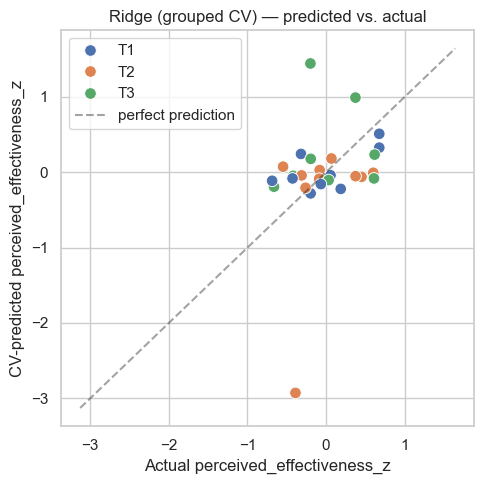

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=y, y=pred_ridge, hue=model_df["task"], ax=ax, s=70)
lims = [min(y.min(), pred_ridge.min()) - 0.2, max(y.max(), pred_ridge.max()) + 0.2]
ax.plot(lims, lims, "k--", alpha=0.4, label="perfect prediction")
ax.set_xlabel("Actual perceived_effectiveness_z")
ax.set_ylabel("CV-predicted perceived_effectiveness_z")
ax.set_title("Ridge (grouped CV) — predicted vs. actual")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Coefficients — what's driving predictions

Fit once on the full n=30 (for interpretability only — not a held-out evaluation, this is the same
`RidgeCV` refit on all data so its chosen alpha and coefficients can be inspected).


Chosen alpha (full-data refit): 5.11


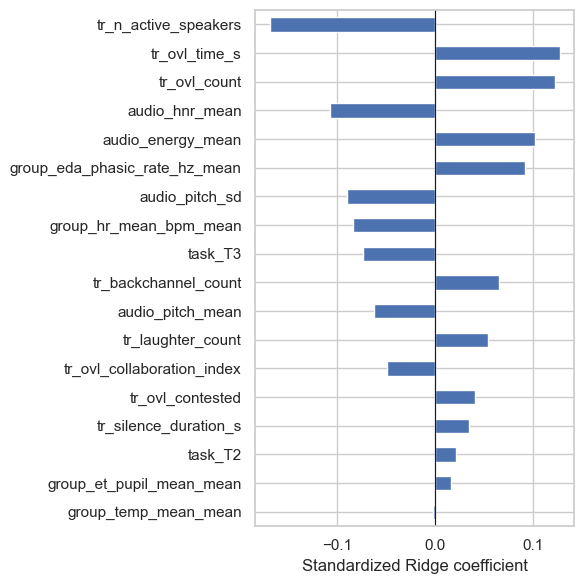

In [9]:
ridge_full = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 25)))
ridge_full.fit(X, y)
chosen_alpha = ridge_full.named_steps["ridgecv"].alpha_

coefs = pd.Series(ridge_full.named_steps["ridgecv"].coef_, index=X_COLS).sort_values(key=np.abs, ascending=False)
print(f"Chosen alpha (full-data refit): {chosen_alpha:.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
coefs.plot(kind="barh", ax=ax)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Standardized Ridge coefficient")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Univariate screen — does any single feature carry signal?

Before trusting a 16-predictor model at n=27, check whether any *individual* feature correlates
with the target at all. This is the fastest honest sanity check and doesn't depend on
regularization/CV choices.


In [ ]:
univariate = []
for c in FEATURE_COLS:
    rho, p = spearmanr(model_df[c], model_df[Y_COL])
    univariate.append({"feature": c, "spearman_rho": rho, "p": p})
univariate = pd.DataFrame(univariate).sort_values("spearman_rho", key=np.abs, ascending=False).reset_index(drop=True)
univariate.round(3)


## 9. Window-level model (n≈500) with predict-then-aggregate

The group×task model only has n=27 to learn 16 predictors from — one bad group-task can swing the
whole CV result (see the T2 outlier in the scatter plot above). An alternative that uses the same
features and the same target, but far more training rows: fit on **windows** (~500 rows, target
repeated within each group×task — pseudo-replicated, so its raw R²/rho aren't directly comparable
to the task-level numbers), then **average the out-of-fold window predictions back up to
group×task** before scoring. Averaging ~20 noisy window-level predictions per group-task is a
free variance-reduction step (same principle as bagging) and is a fairer test of whether the
window-level information helps once its own noise is averaged out.


In [ ]:
window_df = clean.merge(
    target_task.rename(columns={"task": "task_id"}),
    on=["group_id", "task_id"],
    how="inner",
)
window_task_dummies = pd.get_dummies(window_df["task_id"], prefix="task", drop_first=True)
window_df = pd.concat([window_df, window_task_dummies], axis=1)

Xw = window_df[X_COLS].to_numpy(dtype=float)
yw = window_df[Y_COL].to_numpy(dtype=float)
groups_w = window_df["group_id"].to_numpy()

cv_w = GroupKFold(n_splits=model_df["group_id"].nunique())
pipe_w = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 25)))
window_df["pred_w"] = cross_val_predict(pipe_w, Xw, yw, cv=cv_w, groups=groups_w)

agg_pred = (
    window_df.groupby(["group_id", "task_id"])["pred_w"].mean()
    .reset_index().rename(columns={"task_id": "task", "pred_w": "pred_ridge_windowagg"})
)
compare = model_df.merge(agg_pred, on=["group_id", "task"], how="inner")

r2_wa = r2_score(compare[Y_COL], compare["pred_ridge_windowagg"])
rho_wa, p_wa = spearmanr(compare[Y_COL], compare["pred_ridge_windowagg"])
results_by_model = results.set_index("model")

print(f"Window-trained, task-aggregated Ridge: R2={r2_wa:.3f}, spearman_rho={rho_wa:.3f} (p={p_wa:.3f})")
print(f"Task-level Ridge (section 6):          R2={results_by_model.loc['Ridge (grouped CV)', 'R2']:.3f}, "
      f"spearman_rho={results_by_model.loc['Ridge (grouped CV)', 'spearman_rho']:.3f}")
print(f"Mean-only baseline (section 6):        R2={results_by_model.loc['Mean-only baseline', 'R2']:.3f}, "
      f"spearman_rho={results_by_model.loc['Mean-only baseline', 'spearman_rho']:.3f}")


## 8. Conclusions & next steps

- **This is a first pass, not a final model.** n=30 (group×task) is small; treat R²/rho here as a
  sanity check ("is there any signal at all") rather than a publishable result.
- **If Ridge doesn't clearly beat the mean-only baseline**, that's a legitimate finding at this
  sample size, not a failure — it means either (a) more groups are needed, (b) the signal lives at
  window-level dynamics rather than task-level means, or (c) effectiveness perception depends more
  on unmeasured factors (personality, task content) than on these multimodal signals alone.
- **Natural next steps, roughly in order of effort:**
  1. Add `group_hr_mean_bpm_std` / `tr_ovl_smooth` / other "robustness" candidates from
     `icmi_paper/feature_inventory.md` §9.5 if the current set underperforms.
  2. Try the **full eGeMAPS set** (62 params in `audio_window_features.tsv`, `gemap_*` columns)
     with a feature-selection step (e.g. `RidgeCV` on PCA components, or univariate filtering)
     instead of the curated 4 audio summary features.
  3. Move to **window-level modeling**: keep 526 rows, repeat the group×task target across windows,
     still use `GroupKFold` by `group_id` to prevent leakage — trades pseudo-replication for far
     more training data, useful once you also want within-task dynamics (e.g. "does effectiveness
     correlate with the *trend* of overlap/collaboration over the task, not just its mean").
  4. Try **BFI-44 personality scores** (already linked per-participant, see
     `analysis/stimuli_answers_eda.ipynb`) as additional group-level covariates.
  5. If moving beyond linear models, note n=30 really only supports 1-2 effective parameters beyond
     regularized linear — a tree ensemble is not appropriate until window-level (n≈500) is used.
